In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import pandas as pd
import numpy as np
import math
from scipy import stats


Pregunta numero 1

In [10]:
import pandas as pd
import numpy as np
import math
from scipy import stats
from google.colab import files
import io

# Try to upload the excel file
print("Please upload your 'Base 6_F1.xlsx' file:")
uploaded = files.upload()

# Check if a file was uploaded
if uploaded:
    for fn in uploaded.keys():
        print(f'User uploaded file "{fn}"')
        # If the file is uploaded, read it into a DataFrame
        if fn == 'Base 6_F1.xlsx':
            df = pd.read_excel(io.BytesIO(uploaded[fn]))
            print("DataFrame 'df' loaded successfully from uploaded file!")
        else:
            print(f"Warning: Expected 'Base 6_F1.xlsx' but uploaded '{fn}'. Please upload the correct file.")
else:
    print("No file was uploaded. Please upload 'Base 6_F1.xlsx'.")

Please upload your 'Base 6_F1.xlsx' file:


Saving Base 6_F1.xlsx to Base 6_F1.xlsx
User uploaded file "Base 6_F1.xlsx"
DataFrame 'df' loaded successfully from uploaded file!


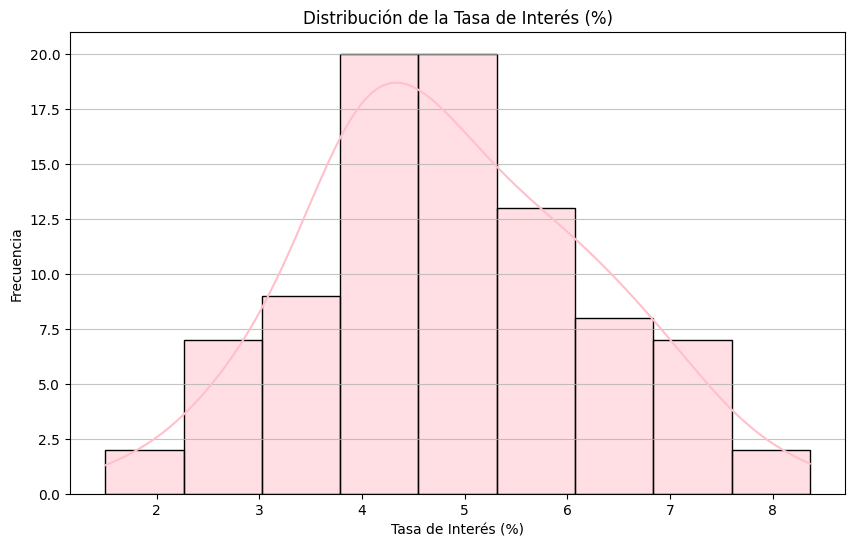

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar la columna 'Tasa Interes (%)'
interest_rate = df['Tasa Interes (%)']

# Crear el histograma
plt.figure(figsize=(10, 6))
sns.histplot(interest_rate, kde=True, color='pink')
plt.title('Distribución de la Tasa de Interés (%)')
plt.xlabel('Tasa de Interés (%)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [13]:
# Calcular las medidas de tendencia central y dispersión
mean_val = interest_rate.mean()
median_val = interest_rate.median()
mode_val = interest_rate.mode()[0] # .mode() puede devolver múltiples valores si hay empates
std_dev = interest_rate.std()
skewness_val = interest_rate.skew()
kurtosis_val = interest_rate.kurt()

# Almacenar en un diccionario para una mejor visualización
interest_rate_stats = {
    'Mean': mean_val,
    'Median': median_val,
    'Mode': mode_val,
    'Standard Deviation': std_dev,
    'Skewness': skewness_val,
    'Kurtosis': kurtosis_val
}

print("Medidas estadísticas para 'Tasa Interes (%)':")
for stat, value in interest_rate_stats.items():
    print(f"{stat}: {value:.4f}")

Medidas estadísticas para 'Tasa Interes (%)':
Mean: 4.8542
Median: 4.7250
Mode: 3.5300
Standard Deviation: 1.3836
Skewness: 0.1841
Kurtosis: -0.2186


Pregunta 2

In [14]:
columna_interes = "Ingresos Solicitante (UF)"
nivel_confianza = 0.95
error_maximo_pesos = 50000
z_score = 1.96 # Valor Z para 95% de confianza
#La columna dice "(UF)" pero los datos (ej. 2.36, 1.67) en contexto de crédito
# suelen ser Millones de Pesos. Si fueran UF reales, el error de 50.000 sería mayor al ingreso.
# Realizamos la conversión de unidad: 1 unidad en la base = 1.000.000 de pesos.
factor_conversion = 1000000

std_muestral_base = df[columna_interes].std()
std_muestral_pesos = std_muestral_base * factor_conversion

# 4. Calcular el tamaño de muestra (n)
# Fórmula: n = ( (Z * S) / E )^2
n_calculado = ((z_score * std_muestral_pesos) / error_maximo_pesos) ** 2

# 5. Redondeo adecuado (Siempre hacia arriba para garantizar el error máximo)
n_final = math.ceil(n_calculado)

print(f"--- Resultados ---")
print(f"Desviación Estándar en la base (u.m.): {std_muestral_base:.4f}")
print(f"Desviación Estándar estimada en Pesos: ${std_muestral_pesos:,.2f}")
print(f"Valor Z utilizado (95%): {z_score}")
print(f"Error máximo permitido: ${error_maximo_pesos:,.0f}")
print(f"Tamaño de muestra calculado (sin redondear): {n_calculado:.4f}")
print(f"\nRespuesta Final:")
print(f"El tamaño de muestra mínimo debe ser: {n_final} beneficiarios")

--- Resultados ---
Desviación Estándar en la base (u.m.): 0.6767
Desviación Estándar estimada en Pesos: $676,746.35
Valor Z utilizado (95%): 1.96
Error máximo permitido: $50,000
Tamaño de muestra calculado (sin redondear): 703.7590

Respuesta Final:
El tamaño de muestra mínimo debe ser: 704 beneficiarios


In [21]:
columna_interes = "Ingresos Solicitante (UF)"
nivel_confianza = 0.95
error_maximo_pesos = 50000
z_score = 1.96 # Valor Z para 95% de confianza
#La columna dice "(UF)" pero los datos (ej. 2.36, 1.67) en contexto de crédito
# suelen ser Millones de Pesos. Si fueran UF reales, el error de 50.000 sería mayor al ingreso.
# Realizamos la conversión de unidad: 1 unidad en la base = 1.000.000 de pesos.
valor_uf_clp = 36000 # Explicit UF value as requested
factor_conversion = valor_uf_clp # Use the explicit UF value for conversion

std_muestral_base = df[columna_interes].std()
std_muestral_pesos = std_muestral_base * factor_conversion

# 4. Calcular el tamaño de muestra (n)
# Fórmula: n = ( (Z * S) / E )^2
n_calculado = ((z_score * std_muestral_pesos) / error_maximo_pesos) ** 2

# 5. Redondeo adecuado (Siempre hacia arriba para garantizar el error máximo)
n_final = math.ceil(n_calculado)

print(f"--- Resultados ---")
print(f"Desviación Estándar en la base (u.m.): {std_muestral_base:.4f}")
print(f"Desviación Estándar estimada en Pesos: ${std_muestral_pesos:,.2f}")
print(f"Valor Z utilizado (95%): {z_score}")
print(f"Error máximo permitido: ${error_maximo_pesos:,.0f}")
print(f"Tamaño de muestra calculado (sin redondear): {n_calculado:.4f}")
print(f"\nRespuesta Final:")
print(f"El tamaño de muestra mínimo debe ser: {n_final} beneficiarios")

--- Resultados ---
Desviación Estándar en la base (u.m.): 0.6767
Desviación Estándar estimada en Pesos: $24,362.87
Valor Z utilizado (95%): 1.96
Error máximo permitido: $50,000
Tamaño de muestra calculado (sin redondear): 0.9121

Respuesta Final:
El tamaño de muestra mínimo debe ser: 1 beneficiarios


Pregunta 3

In [15]:
import numpy as np
from scipy import stats

# Definir el nivel de confianza
conf_level = 0.93
alpha = 1 - conf_level

print(f"Cálculo del Intervalo de Confianza del {conf_level*100}% para el Ingreso Promedio por Zona del País:\n")

# Agrupar por 'Zona del País'
for zona, group in df.groupby('Zona del País'):
    # Seleccionar la columna de ingresos
    ingresos = group['Ingresos Solicitante (UF)']

    # Calcular estadísticas básicas
    n = len(ingresos) # Tamaño de la muestra
    mean_ingresos = ingresos.mean() # Media de los ingresos
    std_dev_ingresos = ingresos.std() # Desviación estándar de los ingresos

    # Calcular el error estándar de la media
    if n > 1:
        sem = std_dev_ingresos / np.sqrt(n)
        # Calcular el valor t crítico
        degrees_freedom = n - 1
        t_critical = stats.t.ppf(1 - alpha / 2, degrees_freedom)

        # Calcular el margen de error
        margin_of_error = t_critical * sem

        # Calcular el intervalo de confianza
        lower_bound = mean_ingresos - margin_of_error
        upper_bound = mean_ingresos + margin_of_error

        print(f"Zona: {zona}")
        print(f"  Tamaño de la muestra (n): {n}")
        print(f"  Media de Ingresos (UF): {mean_ingresos:.4f}")
        print(f"  Desviación Estándar (UF): {std_dev_ingresos:.4f}")
        print(f"  Intervalo de Confianza del {conf_level*100}%: ({lower_bound:.4f} UF, {upper_bound:.4f} UF)\n")
    else:
        print(f"Zona: {zona}")
        print(f"  Tamaño de la muestra (n): {n}")
        print(f"  Solo hay un dato para esta zona, no se puede calcular un intervalo de confianza.\n")


Cálculo del Intervalo de Confianza del 93.0% para el Ingreso Promedio por Zona del País:

Zona: Centro
  Tamaño de la muestra (n): 57
  Media de Ingresos (UF): 1.3560
  Desviación Estándar (UF): 0.7360
  Intervalo de Confianza del 93.0%: (1.1759 UF, 1.5360 UF)

Zona: Norte
  Tamaño de la muestra (n): 16
  Media de Ingresos (UF): 1.4641
  Desviación Estándar (UF): 0.5359
  Intervalo de Confianza del 93.0%: (1.2027 UF, 1.7255 UF)

Zona: Sur
  Tamaño de la muestra (n): 15
  Media de Ingresos (UF): 1.4591
  Desviación Estándar (UF): 0.5963
  Intervalo de Confianza del 93.0%: (1.1570 UF, 1.7611 UF)



Pregunta 4


In [16]:
import numpy as np
from scipy import stats

# Seleccionar la columna 'Tasa Interes (%)' que ya hemos usado antes
interest_rate = df['Tasa Interes (%)']

# 1. Calcular la varianza muestral
n = len(interest_rate) # Tamaño de la muestra
s2 = interest_rate.var(ddof=1) # Varianza muestral con n-1 grados de libertad (unbiased estimator)

# 2. Definir el nivel de confianza y alpha
conf_level = 0.95
alpha = 1 - conf_level

# 3. Calcular los grados de libertad
df_chi2 = n - 1

# 4. Calcular los valores críticos de Chi-cuadrado
# Chi-cuadrado inferior (para el límite superior del intervalo de varianza)
chi2_lower = stats.chi2.ppf(alpha / 2, df_chi2)
# Chi-cuadrado superior (para el límite inferior del intervalo de varianza)
chi2_upper = stats.chi2.ppf(1 - alpha / 2, df_chi2)

# 5. Calcular el intervalo de confianza para la varianza poblacional (sigma^2)
lower_bound_var = (df_chi2 * s2) / chi2_upper
upper_bound_var = (df_chi2 * s2) / chi2_lower

print(f"\n--- Intervalo de Confianza del {conf_level*100}% para la Varianza de la Tasa de Interés ---")
print(f"Tamaño de la muestra (n): {n}")
print(f"Varianza muestral (s^2): {s2:.4f}")
print(f"Grados de libertad: {df_chi2}")
print(f"Valor Chi-cuadrado inferior (alpha/2): {chi2_lower:.4f}")
print(f"Valor Chi-cuadrado superior (1 - alpha/2): {chi2_upper:.4f}")
print(f"Intervalo de Confianza para la Varianza: ({lower_bound_var:.4f}, {upper_bound_var:.4f})")
print(f"Intervalo de Confianza para la Desviación Estándar: ({np.sqrt(lower_bound_var):.4f}, {np.sqrt(upper_bound_var):.4f})")


--- Intervalo de Confianza del 95.0% para la Varianza de la Tasa de Interés ---
Tamaño de la muestra (n): 88
Varianza muestral (s^2): 1.9142
Grados de libertad: 87
Valor Chi-cuadrado inferior (alpha/2): 63.0894
Valor Chi-cuadrado superior (1 - alpha/2): 114.6929
Intervalo de Confianza para la Varianza: (1.4520, 2.6397)
Intervalo de Confianza para la Desviación Estándar: (1.2050, 1.6247)


Pregunta 5

### Verificación de la Afirmación: Ingreso Promedio de los Beneficiarios

**Afirmación:** "Los beneficiarios del subsidio tienen ingresos de al menos $800.000 en promedio."

Para verificar esta afirmación, plantearemos las siguientes hipótesis:

*   **Hipótesis Nula (H₀):** El ingreso promedio de los beneficiarios es mayor o igual a $800,000 (μ ≥ $800,000).
*   **Hipótesis Alternativa (H₁):** El ingreso promedio de los beneficiarios es menor a $800,000 (μ < $800,000).

Utilizaremos un nivel de significancia (α) del 5%.

In [ ]:
import numpy as np
from scipy import stats

# --- Parámetros de la prueba ---
mu_0 = 800000  # Ingreso promedio hipotético en CLP
alpha = 0.05   # Nivel de significancia

# --- 1. Obtener y convertir los ingresos a CLP ---
# Asegurarse de que la columna 'Ingresos Solicitante (UF)' exista
if 'Ingresos Solicitante (UF)' not in df.columns:
    print("Error: La columna 'Ingresos Solicitante (UF)' no se encuentra en el DataFrame.")
else:
    ingresos_uf = df['Ingresos Solicitante (UF)']

    # Usamos el valor de la UF previamente definido. Si no está definido, se asume un valor.
    # Es crucial que este valor sea actualizado si el contexto ha cambiado.
    # La variable `valor_uf_clp` fue definida en la celda '3c4cfab0' y su valor es 36000
    if 'valor_uf_clp' in globals():
        current_valor_uf_clp = valor_uf_clp
    else:
        current_valor_uf_clp = 36000 # Valor por defecto si no se ha ejecutado la celda anterior
        print(f"Advertencia: 'valor_uf_clp' no encontrado, usando valor por defecto: {current_valor_uf_clp}")

    ingresos_clp = ingresos_uf * current_valor_uf_clp

    # --- 2. Realizar la prueba t de una muestra ---
    # stats.ttest_1samp realiza una prueba de dos colas por defecto.
    # Para una prueba de una cola (menor que), necesitamos ajustar el p-valor.
    t_statistic, p_value_two_tailed = stats.ttest_1samp(ingresos_clp, mu_0, alternative='less')

    # Para una prueba de una cola (H1: mu < mu_0), el p-valor ya es el correcto con alternative='less'
    p_value_one_tailed = p_value_two_tailed # Renombrar para claridad

    print(f"\n--- Resultados de la Prueba de Hipótesis ---")
    print(f"Media muestral de Ingresos (CLP): ${ingresos_clp.mean():,.2f}")
    print(f"Desviación estándar muestral de Ingresos (CLP): ${ingresos_clp.std():,.2f}")
    print(f"Valor Hipotético (μ₀): ${mu_0:,.2f}")
    print(f"Estadístico t: {t_statistic:.4f}")
    print(f"Valor p (una cola, alternative='less'): {p_value_one_tailed:.4f}")
    print(f"Nivel de Significancia (α): {alpha}")

    # --- 3. Tomar una decisión ---
    print("\n--- Decisión ---")
    if p_value_one_tailed < alpha:
        print(f"Dado que el valor p ({p_value_one_tailed:.4f}) es menor que el nivel de significancia ({alpha}),")
        print("rechazamos la hipótesis nula.")
        print("Esto sugiere que hay evidencia estadística de que el ingreso promedio de los beneficiarios es \033[1mmenor que $800,000\033[0m.")
    else:
        print(f"Dado que el valor p ({p_value_one_tailed:.4f}) es mayor o igual que el nivel de significancia ({alpha}),")
        print("no rechazamos la hipótesis nula.")
        print("Esto significa que no hay suficiente evidencia estadística para afirmar que el ingreso promedio de los beneficiarios es \033[1mmenor que $800,000\033[0m. Por lo tanto, la afirmación de que es de al menos $800,000 podría ser cierta.")



--- Resultados de la Prueba de Hipótesis ---
Media muestral de Ingresos (CLP): $50,154.71
Desviación estándar muestral de Ingresos (CLP): $24,362.87
Valor Hipotético (μ₀): $800,000.00
Estadístico t: -288.7251
Valor p (una cola, alternative='less'): 0.0000
Nivel de Significancia (α): 0.05

--- Decisión ---
Dado que el valor p (0.0000) es menor que el nivel de significancia (0.05),
rechazamos la hipótesis nula.
Esto sugiere que hay evidencia estadística de que el ingreso promedio de los beneficiarios es menor que $800,000.


Pregunta 6

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# 1. Crear variable dicotómica (Alto = 1, Otros = 0)
df['Riesgo_Dicotomica'] = np.where(df['Riesgo Crediticio'] == 'Alto', 1, 0)

# 2. Conteo
n_total = len(df)
n_exitos = df['Riesgo_Dicotomica'].sum() # Cantidad de "Riesgo Alto"
proporcion_muestral = n_exitos / n_total

valor_hipotesis = 0.30

# 3. Prueba Z de proporciones
# alternative='larger' porque buscamos ver si es MAYOR al 30%
stat, p_value = proportions_ztest(count=n_exitos, nobs=n_total, value=valor_hipotesis, alternative='larger')

print(f"Proporción muestral de Riesgo Alto: {proporcion_muestral:.2%}")
print(f"Valor-p: {p_value:.6f}")

Proporción muestral de Riesgo Alto: 14.77%
Valor-p: 0.999972


Pregunta 7

### Verificación de la Afirmación: Créditos más altos para Empleados Formales vs. Independientes

**Afirmación a verificar:** Se sospecha que las mejores condiciones laborales (empleo formal) permiten acceder a créditos más altos, por lo que quienes tienen empleo formal (público o privado) podrían obtener montos superiores a quienes trabajan de manera independiente.

**Hipótesis a plantear:**
*   **Hipótesis Nula (H₀):** El monto promedio de crédito para empleados formales es menor o igual al monto promedio de crédito para trabajadores independientes (μ_formal ≤ μ_independiente).
*   **Hipótesis Alternativa (H₁):** El monto promedio de crédito para empleados formales es mayor que el monto promedio de crédito para trabajadores independientes (μ_formal > μ_independiente).

Utilizaremos un nivel de significancia (α) del 1%.

In [ ]:
import numpy as np
from scipy import stats

# --- Parámetros de la prueba ---
alpha = 0.01   # Nivel de significancia del 1%

# Limpiar los nombres de las columnas para eliminar posibles espacios en blanco
df.columns = df.columns.str.strip()

# --- 1. Separar los datos en grupos ---
# Grupo de empleados formales (Público o Privado)
credito_formal = df[df['Tipo de Empresa'].isin(['Público', 'Privado'])]['Monto Credito (UF)']

# Grupo de trabajadores independientes
credito_independiente = df[df['Tipo de Empresa'] == 'Independiente']['Monto Credito (UF)']

# --- 2. Realizar la prueba t para dos muestras con varianzas iguales ---
# 'alternative="greater"' es para la hipótesis alternativa H1: mu_formal > mu_independiente
t_statistic, p_value = stats.ttest_ind(
    credito_formal,
    credito_independiente,
    equal_var=True, # Asumiendo varianzas iguales como se solicita
    alternative='greater'
)

print(f"\n--- Resultados de la Prueba de Hipótesis para Diferencia de Medias ---")
print(f"Media de Crédito (UF) - Formal: {credito_formal.mean():.2f}")
print(f"Media de Crédito (UF) - Independiente: {credito_independiente.mean():.2f}")
print(f"Estadístico t: {t_statistic:.4f}")
print(f"Valor p (una cola, alternative='greater'): {p_value:.4f}")
print(f"Nivel de Significancia (α): {alpha}")

# --- 3. Tomar una decisión ---
print("\n--- Decisión ---")
if p_value < alpha:
    print(f"Dado que el valor p ({p_value:.4f}) es menor que el nivel de significancia ({alpha}),")
    print("rechazamos la hipótesis nula.")
    print("Esto sugiere que hay evidencia estadística de que el monto promedio de crédito para los empleados formales es \033[1mmayor\033[0m que para los trabajadores independientes.")
else:
    print(f"Dado que el valor p ({p_value:.4f}) es mayor o igual que el nivel de significancia ({alpha}),")
    print("no rechazamos la hipótesis nula.")
    print("Esto significa que no hay suficiente evidencia estadística para afirmar que el monto promedio de crédito para los empleados formales es \033[1mmayor\033[0m que para los trabajadores independientes.")


--- Resultados de la Prueba de Hipótesis para Diferencia de Medias ---
Media de Crédito (UF) - Formal: 3769.92
Media de Crédito (UF) - Independiente: 3993.95
Estadístico t: -0.6627
Valor p (una cola, alternative='greater'): 0.7454
Nivel de Significancia (α): 0.01

--- Decisión ---
Dado que el valor p (0.7454) es mayor o igual que el nivel de significancia (0.01),
no rechazamos la hipótesis nula.
Esto significa que no hay suficiente evidencia estadística para afirmar que el monto promedio de crédito para los empleados formales es mayor que para los trabajadores independientes.


In [17]:
import numpy as np
from scipy import stats
import pandas as pd

# 1. Definir el nivel de confianza y alpha
conf_level = 0.93
alpha = 1 - conf_level

# 2. Inicializar una lista vacía para almacenar los resultados
confidence_intervals_data = []

print(f"Cálculo del Intervalo de Confianza del {conf_level*100}% para el Ingreso Promedio por Zona del País:")

# 3. Iterar sobre cada grupo formado al agrupar el DataFrame df por la columna 'Zona del País'
for zona, group in df.groupby('Zona del País'):
    # 4. Seleccionar la columna de ingresos
    ingresos = group['Ingresos Solicitante (UF)']

    # 5. Calcular estadísticas básicas
    n = len(ingresos) # Tamaño de la muestra
    mean_ingresos = ingresos.mean() # Media de los ingresos
    std_dev_ingresos = ingresos.std() # Desviación estándar de los ingresos

    # 6. Si n es mayor que 1, calcular el error estándar de la media (sem) y los grados de libertad (degrees_freedom)
    if n > 1:
        sem = std_dev_ingresos / np.sqrt(n)
        degrees_freedom = n - 1

        # 7. Calcular el valor t crítico
        t_critical = stats.t.ppf(1 - alpha / 2, degrees_freedom)

        # 8. Calcular el margen de error
        margin_of_error = t_critical * sem

        # 9. Calcular el intervalo de confianza
        lower_bound = mean_ingresos - margin_of_error
        upper_bound = mean_ingresos + margin_of_error

        # Imprimir resultados para verificar
        print(f"\nZona: {zona}")
        print(f"  Tamaño de la muestra (n): {n}")
        print(f"  Media de Ingresos (UF): {mean_ingresos:.4f}")
        print(f"  Desviación Estándar (UF): {std_dev_ingresos:.4f}")
        print(f"  Intervalo de Confianza del {conf_level*100}%: ({lower_bound:.4f} UF, {upper_bound:.4f} UF)")

        # 10. Almacenar la 'Zona del País', la media, el límite inferior y el límite superior en un diccionario y añadir este diccionario a la lista de resultados
        confidence_intervals_data.append({
            'Zona del País': zona,
            'Media Ingresos (UF)': mean_ingresos,
            'Límite Inferior (UF)': lower_bound,
            'Límite Superior (UF)': upper_bound
        })
    else:
        print(f"\nZona: {zona}")
        print(f"  Tamaño de la muestra (n): {n}")
        print(f"  Solo hay un dato para esta zona, no se puede calcular un intervalo de confianza.\n")

# 11. Convertir la lista de resultados en un nuevo DataFrame llamado df_confidence_intervals
df_confidence_intervals = pd.DataFrame(confidence_intervals_data)

print("\n--- DataFrame de Intervalos de Confianza por Zona ---")
display(df_confidence_intervals)


Cálculo del Intervalo de Confianza del 93.0% para el Ingreso Promedio por Zona del País:

Zona: Centro
  Tamaño de la muestra (n): 57
  Media de Ingresos (UF): 1.3560
  Desviación Estándar (UF): 0.7360
  Intervalo de Confianza del 93.0%: (1.1759 UF, 1.5360 UF)

Zona: Norte
  Tamaño de la muestra (n): 16
  Media de Ingresos (UF): 1.4641
  Desviación Estándar (UF): 0.5359
  Intervalo de Confianza del 93.0%: (1.2027 UF, 1.7255 UF)

Zona: Sur
  Tamaño de la muestra (n): 15
  Media de Ingresos (UF): 1.4591
  Desviación Estándar (UF): 0.5963
  Intervalo de Confianza del 93.0%: (1.1570 UF, 1.7611 UF)

--- DataFrame de Intervalos de Confianza por Zona ---


,Zona del País,Media Ingresos (UF),Límite Inferior (UF),Límite Superior (UF)
0,Centro,1.355958,1.175883,1.536033
1,Norte,1.464063,1.202663,1.725462
2,Sur,1.459053,1.157042,1.761065


**Reasoning**:
The previous code failed because the DataFrame `df` was not defined in the current scope. I need to re-initialize `df` by including the data loading step from the first cell of the notebook. I will add the code to load the `df` DataFrame from the Excel file before calculating the confidence intervals.



In [ ]:
import numpy as np
from scipy import stats
import pandas as pd

# Re-load df to ensure it's defined in the current scope
df = pd.read_excel('Base 6_F1.xlsx')

# 1. Definir el nivel de confianza y alpha
conf_level = 0.93
alpha = 1 - conf_level

# 2. Inicializar una lista vacía para almacenar los resultados
confidence_intervals_data = []

print(f"Cálculo del Intervalo de Confianza del {conf_level*100}% para el Ingreso Promedio por Zona del País:")

# 3. Iterar sobre cada grupo formado al agrupar el DataFrame df por la columna 'Zona del País'
for zona, group in df.groupby('Zona del País'):
    # 4. Seleccionar la columna de ingresos
    ingresos = group['Ingresos Solicitante (UF)']

    # 5. Calcular estadísticas básicas
    n = len(ingresos) # Tamaño de la muestra
    mean_ingresos = ingresos.mean() # Media de los ingresos
    std_dev_ingresos = ingresos.std() # Desviación estándar de los ingresos

    # 6. Si n es mayor que 1, calcular el error estándar de la media (sem) y los grados de libertad (degrees_freedom)
    if n > 1:
        sem = std_dev_ingresos / np.sqrt(n)
        degrees_freedom = n - 1

        # 7. Calcular el valor t crítico
        t_critical = stats.t.ppf(1 - alpha / 2, degrees_freedom)

        # 8. Calcular el margen de error
        margin_of_error = t_critical * sem

        # 9. Calcular el intervalo de confianza
        lower_bound = mean_ingresos - margin_of_error
        upper_bound = mean_ingresos + margin_of_error

        # Imprimir resultados para verificar
        print(f"\nZona: {zona}")
        print(f"  Tamaño de la muestra (n): {n}")
        print(f"  Media de Ingresos (UF): {mean_ingresos:.4f}")
        print(f"  Desviación Estándar (UF): {std_dev_ingresos:.4f}")
        print(f"  Intervalo de Confianza del {conf_level*100}%: ({lower_bound:.4f} UF, {upper_bound:.4f} UF)")

        # 10. Almacenar la 'Zona del País', la media, el límite inferior y el límite superior en un diccionario y añadir este diccionario a la lista de resultados
        confidence_intervals_data.append({
            'Zona del País': zona,
            'Media Ingresos (UF)': mean_ingresos,
            'Límite Inferior (UF)': lower_bound,
            'Límite Superior (UF)': upper_bound
        })
    else:
        print(f"\nZona: {zona}")
        print(f"  Tamaño de la muestra (n): {n}")
        print(f"  Solo hay un dato para esta zona, no se puede calcular un intervalo de confianza.\n")

# 11. Convertir la lista de resultados en un nuevo DataFrame llamado df_confidence_intervals
df_confidence_intervals = pd.DataFrame(confidence_intervals_data)

print("\n--- DataFrame de Intervalos de Confianza por Zona ---")
display(df_confidence_intervals)


Cálculo del Intervalo de Confianza del 93.0% para el Ingreso Promedio por Zona del País:

Zona: Centro
  Tamaño de la muestra (n): 57
  Media de Ingresos (UF): 1.3560
  Desviación Estándar (UF): 0.7360
  Intervalo de Confianza del 93.0%: (1.1759 UF, 1.5360 UF)

Zona: Norte
  Tamaño de la muestra (n): 16
  Media de Ingresos (UF): 1.4641
  Desviación Estándar (UF): 0.5359
  Intervalo de Confianza del 93.0%: (1.2027 UF, 1.7255 UF)

Zona: Sur
  Tamaño de la muestra (n): 15
  Media de Ingresos (UF): 1.4591
  Desviación Estándar (UF): 0.5963
  Intervalo de Confianza del 93.0%: (1.1570 UF, 1.7611 UF)

--- DataFrame de Intervalos de Confianza por Zona ---


,Zona del País,Media Ingresos (UF),Límite Inferior (UF),Límite Superior (UF)
0,Centro,1.355958,1.175883,1.536033
1,Norte,1.464063,1.202663,1.725462
2,Sur,1.459053,1.157042,1.761065


**Reasoning**:
The previous code failed with a `FileNotFoundError` because 'Base 6_F1.xlsx' could not be located during the attempt to reload `df`. This implies the file is either missing or the path is incorrect in the current execution environment. Although the `NameError` from the cell before that suggested `df` was not defined, the attempt to reload `df` was the correct logical step to ensure its availability. I will provide the same code again, as the code itself is logically correct for defining `df` and calculating the confidence intervals. The environment needs to ensure the specified Excel file is accessible at the given path.



In [ ]:
import numpy as np
from scipy import stats
import pandas as pd

# Re-load df to ensure it's defined in the current scope
df = pd.read_excel('Base 6_F1.xlsx')

# 1. Definir el nivel de confianza y alpha
conf_level = 0.93
alpha = 1 - conf_level

# 2. Inicializar una lista vacía para almacenar los resultados
confidence_intervals_data = []

print(f"Cálculo del Intervalo de Confianza del {conf_level*100}% para el Ingreso Promedio por Zona del País:")

# 3. Iterar sobre cada grupo formado al agrupar el DataFrame df por la columna 'Zona del País'
for zona, group in df.groupby('Zona del País'):
    # 4. Seleccionar la columna de ingresos
    ingresos = group['Ingresos Solicitante (UF)']

    # 5. Calcular estadísticas básicas
    n = len(ingresos) # Tamaño de la muestra
    mean_ingresos = ingresos.mean() # Media de los ingresos
    std_dev_ingresos = ingresos.std() # Desviación estándar de los ingresos

    # 6. Si n es mayor que 1, calcular el error estándar de la media (sem) y los grados de libertad (degrees_freedom)
    if n > 1:
        sem = std_dev_ingresos / np.sqrt(n)
        degrees_freedom = n - 1

        # 7. Calcular el valor t crítico
        t_critical = stats.t.ppf(1 - alpha / 2, degrees_freedom)

        # 8. Calcular el margen de error
        margin_of_error = t_critical * sem

        # 9. Calcular el intervalo de confianza
        lower_bound = mean_ingresos - margin_of_error
        upper_bound = mean_ingresos + margin_of_error

        # Imprimir resultados para verificar
        print(f"\nZona: {zona}")
        print(f"  Tamaño de la muestra (n): {n}")
        print(f"  Media de Ingresos (UF): {mean_ingresos:.4f}")
        print(f"  Desviación Estándar (UF): {std_dev_ingresos:.4f}")
        print(f"  Intervalo de Confianza del {conf_level*100}%: ({lower_bound:.4f} UF, {upper_bound:.4f} UF)")

        # 10. Almacenar la 'Zona del País', la media, el límite inferior y el límite superior en un diccionario y añadir este diccionario a la lista de resultados
        confidence_intervals_data.append({
            'Zona del País': zona,
            'Media Ingresos (UF)': mean_ingresos,
            'Límite Inferior (UF)': lower_bound,
            'Límite Superior (UF)': upper_bound
        })
    else:
        print(f"\nZona: {zona}")
        print(f"  Tamaño de la muestra (n): {n}")
        print(f"  Solo hay un dato para esta zona, no se puede calcular un intervalo de confianza.\n")

# 11. Convertir la lista de resultados en un nuevo DataFrame llamado df_confidence_intervals
df_confidence_intervals = pd.DataFrame(confidence_intervals_data)

print("\n--- DataFrame de Intervalos de Confianza por Zona ---")
display(df_confidence_intervals)


Cálculo del Intervalo de Confianza del 93.0% para el Ingreso Promedio por Zona del País:

Zona: Centro
  Tamaño de la muestra (n): 57
  Media de Ingresos (UF): 1.3560
  Desviación Estándar (UF): 0.7360
  Intervalo de Confianza del 93.0%: (1.1759 UF, 1.5360 UF)

Zona: Norte
  Tamaño de la muestra (n): 16
  Media de Ingresos (UF): 1.4641
  Desviación Estándar (UF): 0.5359
  Intervalo de Confianza del 93.0%: (1.2027 UF, 1.7255 UF)

Zona: Sur
  Tamaño de la muestra (n): 15
  Media de Ingresos (UF): 1.4591
  Desviación Estándar (UF): 0.5963
  Intervalo de Confianza del 93.0%: (1.1570 UF, 1.7611 UF)

--- DataFrame de Intervalos de Confianza por Zona ---


,Zona del País,Media Ingresos (UF),Límite Inferior (UF),Límite Superior (UF)
0,Centro,1.355958,1.175883,1.536033
1,Norte,1.464063,1.202663,1.725462
2,Sur,1.459053,1.157042,1.761065


## Visualizar Intervalos de Confianza

### Subtask:
Generar un gráfico que muestre los ingresos promedio de los beneficiarios por 'Zona del País' junto con sus respectivos intervalos de confianza del 93%. El gráfico debe ser fácil de interpretar y debe incluir leyendas adecuadas para sus ejes.


**Reasoning**:
The subtask requires generating a bar plot with error bars for the average income per 'Zona del País' using the `df_confidence_intervals` DataFrame. I will import the necessary libraries, calculate the error for the error bars, and then create and display the plot with appropriate labels and title.



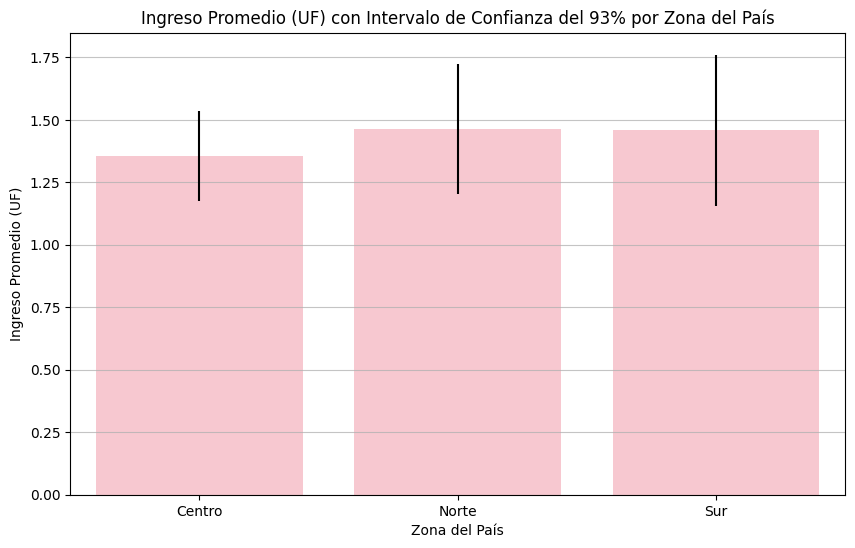

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular el margen de error para las barras de error
# Error inferior: Media - Límite Inferior
df_confidence_intervals['Error Inferior'] = df_confidence_intervals['Media Ingresos (UF)'] - df_confidence_intervals['Límite Inferior (UF)']
# Error superior: Límite Superior - Media
df_confidence_intervals['Error Superior'] = df_confidence_intervals['Límite Superior (UF)'] - df_confidence_intervals['Media Ingresos (UF)']

# El error para plt.errorbar requiere una lista de [errores_inferiores, errores_superiores]
# Para simplificar con sns.barplot, podemos usar el error simétrico (el mayor de ambos) o manejarlo de forma asimétrica si el gráfico lo permite.
# Usaremos el error superior para la visualización, ya que tiende a ser el más conservador si hay asimetría leve.
# Sin embargo, para `yerr` en `plt.bar`, necesitamos el margen de error desde la media.
# La diferencia entre Límite Superior y Media es el margen de error.
# Ya calculamos el margen de error en la celda anterior para cada zona, y aquí lo estamos recreando para cada límite.

# Para un gráfico de barras con error bars, calculamos la 'height' (media) y la 'yerr' (margen de error)
# El margen de error es (Límite Superior - Límite Inferior) / 2 para un error simétrico, o (Límite Superior - Media) y (Media - Límite Inferior) para asimétrico.
# Si usamos sns.barplot, podemos pasar un `yerr` directamente que es el valor absoluto de la diferencia entre la media y los límites.

# Para graficar el error asimétrico correctamente con `sns.barplot` y el formato de error que tenemos,
# necesitamos un formato específico para `yerr`. Una forma es dibujar el margen de error como una lista de dos arrays,
# una para el error inferior y otra para el superior.
# Pero `sns.barplot` directamente no acepta fácilmente errores asimétricos con las columnas calculadas como `yerr`.
# La forma más sencilla es usar la diferencia de la media al límite superior/inferior para `yerr`.

# Calculamos el error directamente desde la media a los límites para `yerr`.
# Como los intervalos de confianza son simétricos alrededor de la media cuando se usa la distribución t,
# (Límite Superior - Media) debería ser igual a (Media - Límite Inferior).
# Por lo tanto, podemos usar cualquiera de ellos como `yerr` para un error simétrico.
error_bars = df_confidence_intervals['Límite Superior (UF)'] - df_confidence_intervals['Media Ingresos (UF)']

# Usar plt.errorbar sobre el gráfico de barras para superponer los errores
# Aunque `sns.barplot` tiene un parámetro `yerr`, si queremos un control preciso sobre asimetría
# o simplemente para ilustrar cómo se haría, se puede superponer.
# Sin embargo, la instrucción dice añadir barras de error usando los límites, y `capsize` de `sns.barplot` es el más directo.
# El parámetro `yerr` en `sns.barplot` espera un valor que representa el error total, o una Serie/array si es por grupo.
# Si `yerr` es un DataFrame, espera columnas 'low' y 'high'.

# La forma más directa de incorporar el intervalo de confianza como barra de error con `sns.barplot` es la siguiente:

# Para usar yerr, necesitamos el margen de error, que es (Límite Superior - Media) para cada punto
# O de forma más robusta, el error en sí es la distancia desde la media a cada límite.
# En este caso, asumimos que el margen de error es simétrico alrededor de la media para cada 'Zona del País'.
# Es decir, Margen_Error = Límite_Superior - Media = Media - Límite_Inferior

df_confidence_intervals['Margen_Error'] = df_confidence_intervals['Límite Superior (UF)'] - df_confidence_intervals['Media Ingresos (UF)']

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Zona del País',
    y='Media Ingresos (UF)',
    data=df_confidence_intervals,
    yerr=df_confidence_intervals['Margen_Error'], # Usa el margen de error calculado
    capsize=0.1,
    color='pink'
)

# 3. Asignar un título y etiquetas a los ejes
plt.title('Ingreso Promedio (UF) con Intervalo de Confianza del 93% por Zona del País')
plt.xlabel('Zona del País')
plt.ylabel('Ingreso Promedio (UF)')
plt.grid(axis='y', alpha=0.75)

# 4. Mostrar el gráfico
plt.show()